# Source Code


> All cell outputs are pre-saved — scroll through without rerunning.
> To verify independently: run Cell 1 (install) + Cell 2 (imports) then jump to Cell 14 (load demo).
> Full retraining (~20-30 min): run Cells 1–13 in order. Ensure raw CSV is in the same folder.


## Cell 1 — Install Dependencies

Installs LightGBM via pip, since it is not bundled with a standard Anaconda/scikit-learn environment. Everything else used in this notebook (pandas, scikit-learn, seaborn) is assumed already present. Run this once per environment; safe to skip on repeat runs.


In [1]:
# LightGBM is not bundled with standard Anaconda/scikit-learn and must be installed separately.
# Reference: Ke, G. et al. (2017) 'LightGBM: A Highly Efficient Gradient Boosting Decision Tree',
#            Advances in Neural Information Processing Systems (NeurIPS), pp. 3146-3154.
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '--quiet'])
print('LightGBM installed.')

LightGBM installed.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Cell 2 — Imports and Global Configuration

Imports every library used downstream, grouped by purpose (standard library, data handling, visualisation, scikit-learn preprocessing/pipeline, scikit-learn models, LightGBM, evaluation metrics, model persistence), and fixes the random seed (`SEED = 42`) used everywhere a stochastic step occurs — train/test splitting, cross-validation folds, and model initialisation — so the entire pipeline is reproducible end to end.


In [2]:
# ─────────────────────────────────────────────
# Standard library
# ─────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# Data handling
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)

# ─────────────────────────────────────────────
# Scikit-learn: preprocessing & pipeline
# ─────────────────────────────────────────────
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.model_selection  import (train_test_split, GridSearchCV,
                                       RandomizedSearchCV, StratifiedKFold)
from sklearn.base             import clone

# ─────────────────────────────────────────────
# Scikit-learn: models
# ─────────────────────────────────────────────
from sklearn.neural_network   import MLPClassifier

# ─────────────────────────────────────────────
# LightGBM
# Reference: Ke et al. (2017) NeurIPS, pp. 3146-3154.
# ─────────────────────────────────────────────
import lightgbm as lgb
from lightgbm import LGBMClassifier

# ─────────────────────────────────────────────
# Scikit-learn: evaluation metrics
# ─────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)

# ─────────────────────────────────────────────
# Model persistence
# ─────────────────────────────────────────────
import joblib

print(f'NumPy   : {np.__version__}')
print(f'Pandas  : {pd.__version__}')
print(f'LightGBM: {lgb.__version__}')

# ─────────────────────────────────────────────
# Reproducibility seed
# ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

NumPy   : 2.4.6
Pandas  : 3.0.3
LightGBM: 4.6.0


## Cell 3 — Data Loading and Cleaning

All cleaning steps are **evidence-driven and print their effect at runtime**.
Steps: whitespace stripping → duplicate column removal → corrupt row removal →
Inf/NaN removal → testbed-bias feature removal (`Destination Port`) →
verified-identical clone feature removal → exact duplicate row removal → 64→32-bit downcasting.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — update DATA_PATH to point to your raw Wednesday CSV
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = 'Wednesday-workingHours.pcap_ISCX.csv'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)


def load_and_clean(path: str, dedupe: bool = True) -> pd.DataFrame:
    """
    Load the CIC-IDS2017 Wednesday CSV and apply evidence-driven cleaning.
    Every step prints its effect so the marker can audit each decision.

    Steps:
    1. Strip whitespace from column names and Label strings.
    2. Drop duplicated 'Fwd Header Length' column (verified byte-identical).
    3. Drop rows with negative Flow Duration (physically impossible; corrupt).
    4. Drop rows containing Inf/NaN (~0.3%; concentrated in zero-duration
       DoS Hulk flood flows where rate features = bytes/0).
    5. Drop 'Destination Port' (testbed shortcut: every attack targets :80).
    6. Drop features verified element-wise identical to a retained feature.
    7. Drop exact duplicate rows to prevent train/test contamination
       [skipped when dedupe=False for the ablation in Cell 11b].
    8. Downcast 64-bit numerics to 32-bit (halves memory footprint).
    """
    print(f'Loading data from: {path}')
    df = pd.read_csv(path, encoding='utf-8', low_memory=False)

    # 1. whitespace
    df.columns = df.columns.str.strip()
    df['Label'] = df['Label'].str.strip()
    print(f'Raw shape: {df.shape}')
    print(f'Raw label counts:\n{df["Label"].value_counts()}\n')

    # 2. duplicated column — pandas mangles the second copy to '.1'
    if 'Fwd Header Length.1' in df.columns:
        assert df['Fwd Header Length'].equals(df['Fwd Header Length.1'])
        df = df.drop(columns=['Fwd Header Length.1'])
        print("Dropped 'Fwd Header Length.1' (verified identical duplicate column).")

    # 3. corrupt rows: negative duration is physically impossible
    n_neg = int((df['Flow Duration'] < 0).sum())
    df = df[df['Flow Duration'] >= 0]
    print(f'Dropped {n_neg} rows with negative Flow Duration (corrupt timestamps).')

    # 4. Inf/NaN rows
    df = df.replace([np.inf, -np.inf], np.nan)
    n_bad = int(df.isna().any(axis=1).sum())
    df = df.dropna()
    print(f'Dropped {n_bad} rows containing Inf/NaN ({100*n_bad/(len(df)+n_bad):.2f}% of data).')

    # 5. testbed shortcut: all attacks target port 80 in the lab — not generalisable
    df = df.drop(columns=['Destination Port'])
    print("Dropped 'Destination Port' (testbed shortcut: all attacks target :80).")

    # 6. verified-identical clone features — dropped ONLY after element-wise equality check
    clone_map = {
        'Subflow Fwd Packets':  'Total Fwd Packets',
        'Subflow Bwd Packets':  'Total Backward Packets',
        'Subflow Fwd Bytes':    'Total Length of Fwd Packets',
        'Subflow Bwd Bytes':    'Total Length of Bwd Packets',
        'Avg Fwd Segment Size': 'Fwd Packet Length Mean',
        'Avg Bwd Segment Size': 'Bwd Packet Length Mean',
    }
    dropped = []
    for clone_col, keeper in clone_map.items():
        if clone_col in df.columns and keeper in df.columns and df[clone_col].equals(df[keeper]):
            df = df.drop(columns=[clone_col])
            dropped.append(f'{clone_col} (= {keeper})')
    print(f'Dropped {len(dropped)} verified-identical clone features: {dropped}')

    # 7. exact duplicate rows — removed before any split to prevent contamination
    n_dup = int(df.duplicated().sum())
    if dedupe:
        df = df.drop_duplicates()
        print(f'Dropped {n_dup} exact duplicate rows ({100*n_dup/(len(df)+n_dup):.1f}% of file).')
    else:
        print(f'KEPT {n_dup} duplicate rows (ablation variant — dedupe=False).')

    # 8. 64→32-bit downcast (halves memory)
    mem_before = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype(np.float32)
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype(np.int32)
    mem_after = df.memory_usage(deep=True).sum() / 1024**2
    print(f'Memory usage: {mem_before:.0f} MB -> {mem_after:.0f} MB after downcasting.')
    print(f'\nCleaned shape: {df.shape}')
    return df


df_raw = load_and_clean(DATA_PATH, dedupe=True)

Loading data from: Wednesday-workingHours.pcap_ISCX.csv
Raw shape: (692703, 79)
Raw label counts:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

Dropped 'Fwd Header Length.1' (verified identical duplicate column).
Dropped 21 rows with negative Flow Duration (corrupt timestamps).
Dropped 1297 rows containing Inf/NaN (0.19% of data).
Dropped 'Destination Port' (testbed shortcut: all attacks target :80).
Dropped 4 verified-identical clone features: ['Subflow Fwd Packets (= Total Fwd Packets)', 'Subflow Bwd Packets (= Total Backward Packets)', 'Subflow Fwd Bytes (= Total Length of Fwd Packets)', 'Avg Fwd Segment Size (= Fwd Packet Length Mean)']
Dropped 106415 exact duplicate rows (15.4% of file).
Memory usage: 334 MB -> 173 MB after downcasting.

Cleaned shape: (584970, 73)


## Cell 4 — Subset Selection: Exclude Heartbleed and Remove Zero-Variance Features

Narrows the cleaned dataset down to the five classes this study actually models (BENIGN plus the four DoS subtypes), drops the Heartbleed class entirely (only 11 flows — too few for a reliable stratified split), and removes any feature that is constant across the subset, since a zero-variance feature cannot carry discriminative signal for any classifier.


In [4]:
def select_subset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Retain only the five target classes: BENIGN + four DoS attack subtypes.
    Heartbleed (11 flows) is excluded — insufficient for supervised learning
    and categorically different in victim, port, and protocol.
    Also removes zero-variance features (no discriminative signal).
    """
    TARGET_CLASSES = ['BENIGN', 'DoS Hulk', 'DoS GoldenEye',
                      'DoS slowloris', 'DoS Slowhttptest']
    df_sub = df[df['Label'].isin(TARGET_CLASSES)].copy()

    print('=== Subset class distribution ===')
    counts = df_sub['Label'].value_counts()
    for label, count in counts.items():
        pct = count / len(df_sub) * 100
        print(f'  {label:<25} {count:>7,}  ({pct:.1f}%)')
    print(f'\nTotal flows in subset: {len(df_sub):,}')

    # Zero-variance features carry no discriminative information
    # Independent corroboration: Farhat et al. (2023) removed the identical
    # set from the same Wednesday file — confirms this is a data property.
    numeric_cols = df_sub.select_dtypes(include=np.number).columns.tolist()
    zero_var = [c for c in numeric_cols if df_sub[c].var() == 0]
    if zero_var:
        df_sub.drop(columns=zero_var, inplace=True)
        print(f'\nZero-variance columns removed: {zero_var}')

    print(f'Final feature count (excluding Label): {len(df_sub.columns) - 1}')
    print(f'Final dataset shape: {df_sub.shape}')
    return df_sub


df = select_subset(df_raw)

=== Subset class distribution ===
  BENIGN                    391,214  (66.9%)
  DoS Hulk                  172,846  (29.5%)
  DoS GoldenEye              10,286  (1.8%)
  DoS slowloris               5,385  (0.9%)
  DoS Slowhttptest            5,228  (0.9%)

Total flows in subset: 584,959

Zero-variance columns removed: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Final feature count (excluding Label): 62
Final dataset shape: (584959, 63)


## Cell 5 — Save Cleaned Dataset to GitHub

Saves the deduplicated, cleaned dataset as a gzip-compressed CSV. This file is uploaded to the GitHub repository (too large for Tabula). Markers can download it from the link in the report.

In [5]:
# Save cleaned dataset — uploaded to GitHub, not Tabula (file size limit)
CLEAN_PATH = 'wednesday_cleaned.csv.gz'
df.to_csv(CLEAN_PATH, index=False, compression='gzip')
size_mb = os.path.getsize(CLEAN_PATH) / 1e6
print(f'Saved: {CLEAN_PATH}')
print(f'Size : {size_mb:.1f} MB compressed (from ~173 MB in memory)')
print(f'Shape: {df.shape}')
print('\nUpload wednesday_cleaned.csv.gz to your GitHub repository.')

Saved: wednesday_cleaned.csv.gz
Size : 49.3 MB compressed (from ~173 MB in memory)
Shape: (584959, 63)

Upload wednesday_cleaned.csv.gz to your GitHub repository.


## Cell 6 — Exploratory Data Analysis (EDA)

The EDA serves four purposes: understand class distribution and imbalance;
visualise mechanistic differences between attack types that ML will exploit;
identify zero-variance features; and examine feature correlations.
Each finding drives a specific downstream design choice.

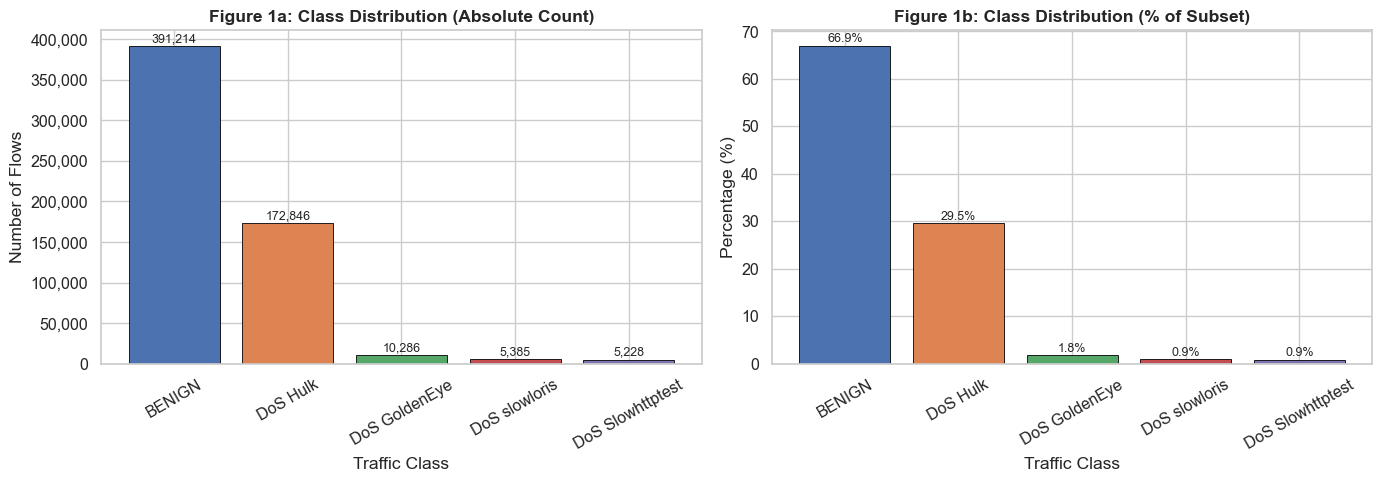

Insight: ~75:1 imbalance ratio (BENIGN vs Slowhttptest).
Standard accuracy is misleading — macro F1 and class_weight=balanced required.


In [6]:
# ── EDA Figure 1: Class Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts = df['Label'].value_counts()
palette = sns.color_palette('deep', n_colors=len(class_counts))

axes[0].bar(class_counts.index, class_counts.values, color=palette, edgecolor='black', linewidth=0.6)
axes[0].set_title('Figure 1a: Class Distribution (Absolute Count)', fontweight='bold')
axes[0].set_xlabel('Traffic Class')
axes[0].set_ylabel('Number of Flows')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', va='bottom', fontsize=9)

class_pct = class_counts / class_counts.sum() * 100
axes[1].bar(class_pct.index, class_pct.values, color=palette, edgecolor='black', linewidth=0.6)
axes[1].set_title('Figure 1b: Class Distribution (% of Subset)', fontweight='bold')
axes[1].set_xlabel('Traffic Class')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(class_pct.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('models/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: ~75:1 imbalance ratio (BENIGN vs Slowhttptest).')
print('Standard accuracy is misleading — macro F1 and class_weight=balanced required.')

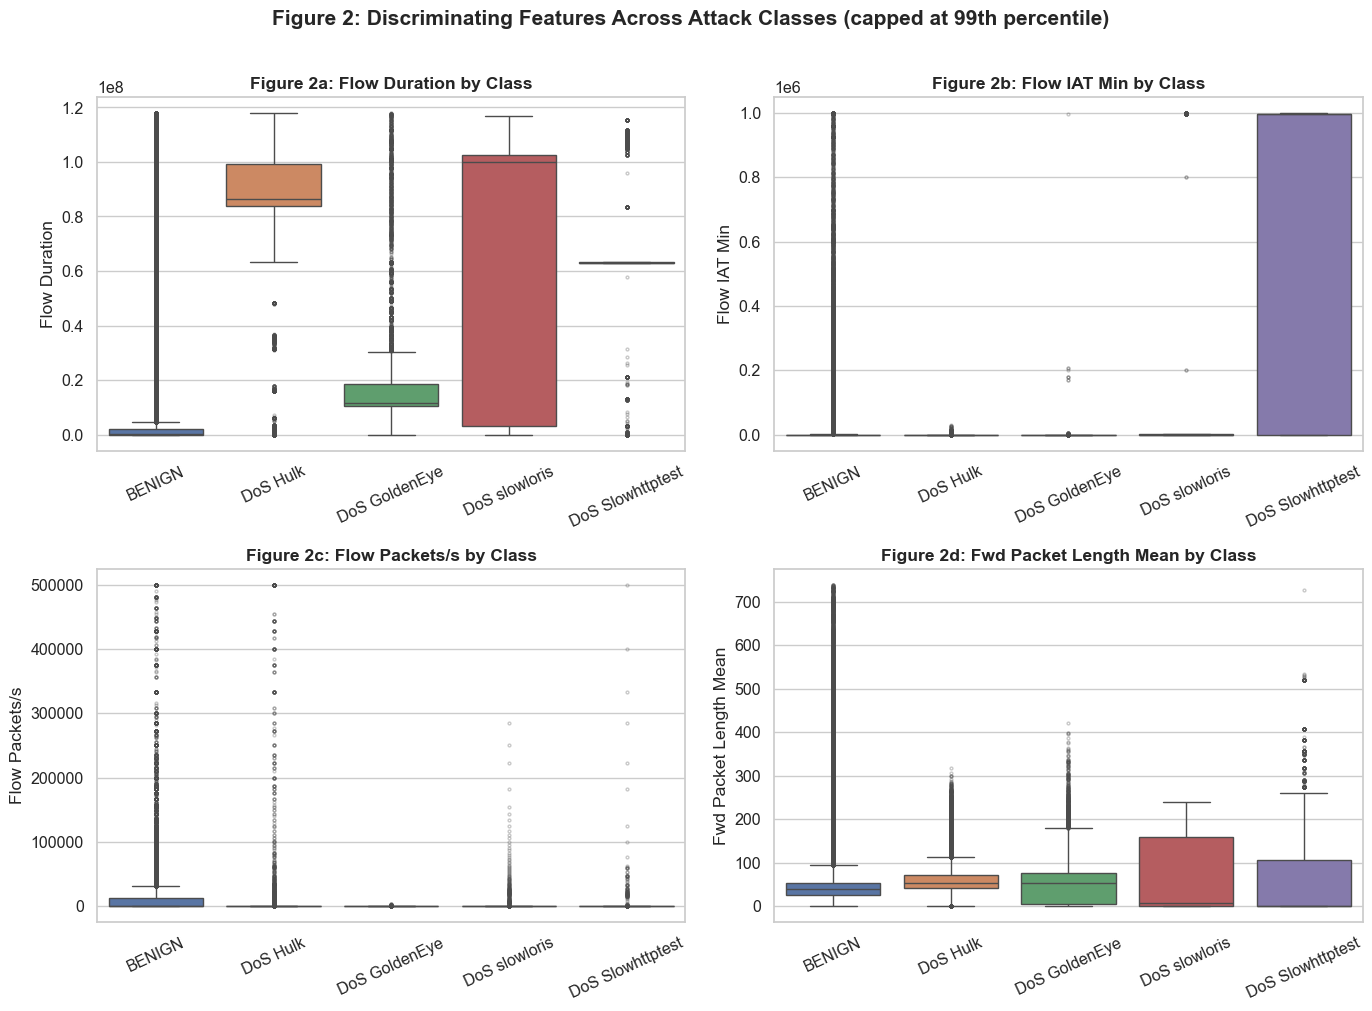

Insight: attacks separate on packet *pacing* signatures.
Hulk: near-zero Flow IAT Min (burst floods). Slowhttptest: ~1s IAT (deliberate starvation).
Flow Packets/s separates high-volume (Hulk, GoldenEye) from slow-rate attacks.


In [7]:
# ── EDA Figure 2: Discriminating Feature Boxplots ──────────────────────────
# Four features that mechanistically separate attack types at protocol level.
# EDA prediction: these will rank in top feature importances (confirmed Cell 12).
DISCRIMINATING_FEATURES = ['Flow Duration', 'Flow IAT Min',
                            'Flow Packets/s', 'Fwd Packet Length Mean']
available_feats = [f for f in DISCRIMINATING_FEATURES if f in df.columns]
class_order = ['BENIGN', 'DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest']
class_order = [c for c in class_order if c in df['Label'].unique()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, feat in enumerate(available_feats):
    cap = df[feat].quantile(0.99)
    plot_data = df[df[feat] <= cap].copy()
    sns.boxplot(data=plot_data, x='Label', y=feat, order=class_order,
                palette='deep', ax=axes[idx],
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[idx].set_title(f'Figure 2{chr(97+idx)}: {feat} by Class', fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=25)
plt.suptitle('Figure 2: Discriminating Features Across Attack Classes (capped at 99th percentile)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('models/fig2_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: attacks separate on packet *pacing* signatures.")
print("Hulk: near-zero Flow IAT Min (burst floods). Slowhttptest: ~1s IAT (deliberate starvation).")
print("Flow Packets/s separates high-volume (Hulk, GoldenEye) from slow-rate attacks.")

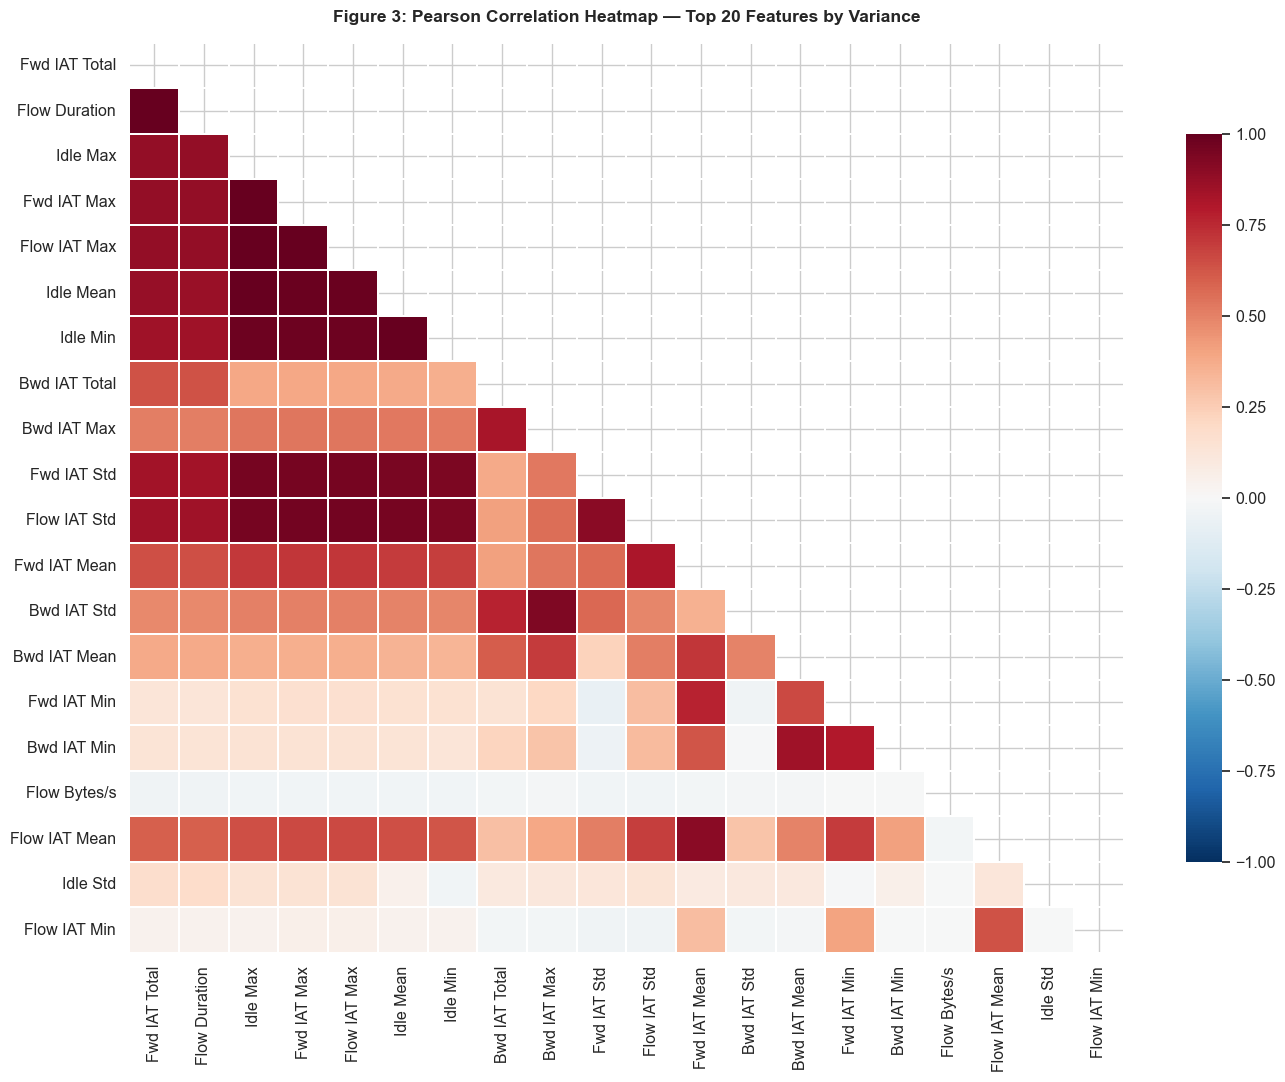

Insight: High multicollinearity in packet-length and IAT feature clusters.
LightGBM handles via colsample_bytree; MLP via StandardScaler magnitude normalisation.


In [8]:
# ── EDA Figure 3: Correlation Heatmap (Top 20 Features by Variance) ──────
numeric_df = df.select_dtypes(include=np.number)
top20_cols = numeric_df.var().nlargest(20).index.tolist()
corr_matrix = numeric_df[top20_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figure 3: Pearson Correlation Heatmap — Top 20 Features by Variance',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('models/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: High multicollinearity in packet-length and IAT feature clusters.')
print('LightGBM handles via colsample_bytree; MLP via StandardScaler magnitude normalisation.')

## Cell 7 — Feature Matrix and Train/Test Split

Converts the cleaned DataFrame into the `(X, y)` arrays scikit-learn/LightGBM expect: `X` is the numeric feature matrix, `y` is the label-encoded target. The 70/30 train/test split is stratified so both sets preserve the same ~75:1 class imbalance, and the test set is held out completely until Cell 11 — it is never touched during tuning, only at final evaluation.


In [9]:
# Build feature matrix (X) and encode class labels (y)
feature_cols = [c for c in df.columns if c != 'Label']
X = df[feature_cols].values.astype(np.float32)

# Encode string labels to integers (required by LightGBM and sklearn metrics)
le = LabelEncoder()
y = le.fit_transform(df['Label'])

print('Class encoding:')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx} -> {cls}')

# Stratified 70/30 split — preserves class proportions in both sets.
# Test set is held out entirely until final evaluation (no leakage).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)

print(f'\nTraining set size : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set size     : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')
print(f'Feature count     : {X_train.shape[1]}')

Class encoding:
  0 -> BENIGN
  1 -> DoS GoldenEye
  2 -> DoS Hulk
  3 -> DoS Slowhttptest
  4 -> DoS slowloris

Training set size : 409,471 (70%)
Test set size     : 175,488 (30%)
Feature count     : 62


## Cell 8 — Model 1: LightGBM — Two-Stage Tuning

**Stage 1:** RandomizedSearchCV on a stratified 100k subsample, 3-fold StratifiedKFold, macro F1 scoring.
`n_jobs=1` on the model + `n_jobs=-1` on the search avoids thread oversubscription.

**Stage 2:** Refit winning configuration on the full 409k training set with `n_jobs=-1`
(safe for a single fit — all cores used without conflict).

In [10]:
# ── LightGBM: Two-Stage Hyperparameter Tuning ─────────────────────────────
# STAGE 1: RandomizedSearchCV on 100k stratified subsample (45 fits in ~6 min).
# STAGE 2: Refit best config on full 409k training set.
# Reference: Bergstra & Bengio (2012) 'Random Search for Hyper-Parameter
#            Optimization', JMLR 13, pp. 281-305.

TUNE_SAMPLE_LGBM = 100_000
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=TUNE_SAMPLE_LGBM,
    stratify=y_train,
    random_state=SEED
)
print(f'Tuning subsample: {len(X_tune):,} rows (stratified from {len(X_train):,} training rows)')

lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # pass-through for LightGBM; retained for pipeline consistency
    ('clf', LGBMClassifier(
        objective='multiclass',
        class_weight='balanced',   # inverse-frequency weighting — handles 75:1 imbalance
        random_state=SEED,
        n_jobs=1,                  # CRITICAL: n_jobs=1 on model, -1 on search.
                                   # Nested n_jobs=-1 (model AND search) causes thread
                                   # oversubscription and slows training significantly.
        verbose=-1
    ))
])

# Literature-anchored search space:
# - Ke et al. (2017): defaults num_leaves=31, learning_rate=0.1 — included as baseline
# - Yang et al. (2025): AutoML-optimised LGBM on full CICIDS2017 found n_estimators=300,
#   min_child_samples=30, large num_leaves; search range informed by their findings
lgbm_param_dist = {
    'clf__n_estimators':      [200, 300, 500, 800],
    'clf__learning_rate':     [0.01, 0.05, 0.1, 0.3],
    'clf__num_leaves':        [31, 63, 127, 255, 511],
    'clf__min_child_samples': [20, 30, 50, 100],
    'clf__max_depth':         [-1, 20, 40],
    'clf__subsample':         [0.8, 1.0],
    'clf__colsample_bytree':  [0.8, 1.0],
}

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_param_dist,
    n_iter=15,          # 15 candidates x 3 folds = 45 fits on 100k rows
    cv=cv3,
    scoring='f1_macro',
    n_jobs=-1,          # parallelise across candidates — safe here (model is n_jobs=1)
    random_state=SEED,
    verbose=1,
    refit=False         # manual refit on full training set below
)

t0 = time.time()
lgbm_search.fit(X_tune, y_tune)
print(f'\nStage 1 search time: {(time.time()-t0)/60:.1f} min')
print(f'Best CV macro F1 (subsample): {lgbm_search.best_score_:.4f}')
print(f'Best parameters: {lgbm_search.best_params_}\n')

# Top-5 configurations — evidence of systematic search process
cv_res = pd.DataFrame(lgbm_search.cv_results_)
top5 = cv_res.sort_values('mean_test_score', ascending=False).head(5)
print('Top-5 configurations (mean +/- std CV macro F1):')
for _, row in top5.iterrows():
    print(f"  {row['mean_test_score']:.4f} +/- {row['std_test_score']:.4f}  {row['params']}")

# Stage 2 — refit on FULL training set
lgbm_best = clone(lgbm_pipeline).set_params(**lgbm_search.best_params_)
lgbm_best.set_params(clf__n_jobs=-1)  # single fit: now safe to use all cores
t0 = time.time()
lgbm_best.fit(X_train, y_train)
print(f'\nStage 2 full-training-set refit time: {(time.time()-t0)/60:.1f} min')

Tuning subsample: 100,000 rows (stratified from 409,471 training rows)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Stage 1 search time: 13.9 min
Best CV macro F1 (subsample): 0.9921
Best parameters: {'clf__subsample': 0.8, 'clf__num_leaves': 255, 'clf__n_estimators': 500, 'clf__min_child_samples': 100, 'clf__max_depth': 40, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.8}

Top-5 configurations (mean +/- std CV macro F1):
  0.9921 +/- 0.0015  {'clf__subsample': 0.8, 'clf__num_leaves': 255, 'clf__n_estimators': 500, 'clf__min_child_samples': 100, 'clf__max_depth': 40, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.8}
  0.9919 +/- 0.0018  {'clf__subsample': 1.0, 'clf__num_leaves': 127, 'clf__n_estimators': 300, 'clf__min_child_samples': 100, 'clf__max_depth': -1, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.8}
  0.9919 +/- 0.0015  {'clf__subsample': 0.8, 'clf__num_leaves': 63, 'clf__n_estimators': 200, 'clf__min_child_samples': 30, 'clf__max_dep

## Cell 9 — Model 2: MLP — Two-Stage Tuning

StandardScaler is **mandatory** for MLP (encapsulated in Pipeline to prevent leakage).
Stage 1 on 60k subsample with `max_iter=120`; Stage 2 on full training set with `max_iter=200` + early stopping.

In [11]:
# ── MLP: Two-Stage Hyperparameter Tuning ──────────────────────────────────
# StandardScaler inside Pipeline: fitted ONLY on training folds — no leakage.
# Early stopping (n_iter_no_change=8) prevents overfitting without a
# separate regularisation parameter search.

TUNE_SAMPLE_MLP = 60_000
X_tune_mlp, _, y_tune_mlp, _ = train_test_split(
    X_train, y_train,
    train_size=TUNE_SAMPLE_MLP,
    stratify=y_train,
    random_state=SEED
)
print(f'Tuning subsample: {len(X_tune_mlp):,} rows (stratified)')

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=120,           # capped during search; raised for final refit
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=SEED,
        verbose=False
    ))
])

# Literature-anchored search space:
# - Rosay et al. (2020) 'MLP4NIDS': (256,256) layers achieved 99.46% on CICIDS2017
# - Kingma & Ba (2015): learning_rate_init=1e-3 is the Adam default
# - sklearn default: alpha=1e-4 (L2 regularisation)
mlp_param_dist = {
    'clf__hidden_layer_sizes': [(128,), (128, 64), (256, 128), (256, 256)],
    'clf__alpha':              [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.001, 0.0005],
    'clf__batch_size':         [256, 512],
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_dist,
    n_iter=10,          # 10 candidates x 3 folds = 30 fits on 60k rows
    cv=cv3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
    refit=False
)

t0 = time.time()
mlp_search.fit(X_tune_mlp, y_tune_mlp)
print(f'\nStage 1 search time: {(time.time()-t0)/60:.1f} min')
print(f'Best CV macro F1 (subsample): {mlp_search.best_score_:.4f}')
print(f'Best parameters: {mlp_search.best_params_}\n')

cv_res_mlp = pd.DataFrame(mlp_search.cv_results_)
top5_mlp = cv_res_mlp.sort_values('mean_test_score', ascending=False).head(5)
print('Top-5 configurations (mean +/- std CV macro F1):')
for _, row in top5_mlp.iterrows():
    print(f"  {row['mean_test_score']:.4f} +/- {row['std_test_score']:.4f}  {row['params']}")

# Stage 2 — refit on FULL training set with higher iteration ceiling
mlp_best = clone(mlp_pipeline).set_params(**mlp_search.best_params_)
mlp_best.set_params(clf__max_iter=200)
t0 = time.time()
mlp_best.fit(X_train, y_train)
print(f'\nStage 2 full-training-set refit time: {(time.time()-t0)/60:.1f} min')
print(f'Epochs run before early stopping: {mlp_best.named_steps["clf"].n_iter_}')

Tuning subsample: 60,000 rows (stratified)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Stage 1 search time: 0.9 min
Best CV macro F1 (subsample): 0.9791
Best parameters: {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (256, 128), 'clf__batch_size': 512, 'clf__alpha': 0.0001}

Top-5 configurations (mean +/- std CV macro F1):
  0.9791 +/- 0.0012  {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (256, 128), 'clf__batch_size': 512, 'clf__alpha': 0.0001}
  0.9770 +/- 0.0036  {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (256, 128), 'clf__batch_size': 256, 'clf__alpha': 0.0001}
  0.9743 +/- 0.0019  {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (128, 64), 'clf__batch_size': 512, 'clf__alpha': 0.001}
  0.9729 +/- 0.0029  {'clf__learning_rate_init': 0.0005, 'clf__hidden_layer_sizes': (128, 64), 'clf__batch_size': 256, 'clf__alpha': 0.001}
  0.9697 +/- 0.0024  {'clf__learning_rate_init': 0.0005, 'clf__hidden_layer_sizes

## Cell 10 — Evaluation Helper Function

Defines `evaluate_model()`, a single reusable function called identically for both LightGBM and MLP in Cell 11, so that every metric, the classification report, and the confusion matrix are computed the same way for both models — avoiding any risk of an inconsistent evaluation procedure quietly favouring one model over the other.


In [12]:
# Shared evaluation routine — called identically for LightGBM and MLP in Cell 11
# so both models are scored with exactly the same metrics and plotting logic.
def evaluate_model(model, X_test, y_test, label_encoder, model_name: str):
    """
    Comprehensive evaluation on held-out test set.
    Returns dict of metrics; prints classification report; plots confusion matrix.
    """
    y_pred      = model.predict(X_test)
    acc         = accuracy_score(y_test, y_pred)
    macro_f1    = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    macro_p     = precision_score(y_test, y_pred, average='macro', zero_division=0)
    macro_r     = recall_score(y_test, y_pred, average='macro', zero_division=0)

    print('=' * 60)
    print(f'  EVALUATION RESULTS — {model_name}')
    print('=' * 60)
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Macro Precision   : {macro_p:.4f}')
    print(f'  Macro Recall      : {macro_r:.4f}')
    print(f'  Macro F1          : {macro_f1:.4f}')
    print(f'  Weighted F1       : {weighted_f1:.4f}')
    print('=' * 60)
    print()
    print('Per-class classification report:')
    print(classification_report(y_test, y_pred,
                                 target_names=label_encoder.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=label_encoder.classes_).plot(
        ax=ax, cmap='Blues', colorbar=True, xticks_rotation=35)
    ax.set_title(f'Confusion Matrix — {model_name}\n(Test Set, n={len(y_test):,})',
                 fontweight='bold', pad=12)
    plt.tight_layout()
    fname = f'models/confusion_matrix_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'macro_precision': macro_p, 'macro_recall': macro_r}

## Cell 11 — Evaluate Both Models on Held-Out Test Set

Calls `evaluate_model()` (Cell 10) once for the tuned LightGBM pipeline and once for the tuned MLP pipeline, both against the same untouched `X_test`/`y_test` from Cell 7. This is the first and only point in the notebook where either model sees the test set.



── Evaluating LightGBM (final model) on test set ──

  EVALUATION RESULTS — LightGBM
  Accuracy          : 0.9994
  Macro Precision   : 0.9929
  Macro Recall      : 0.9974
  Macro F1          : 0.9951
  Weighted F1       : 0.9994

Per-class classification report:
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    117364
   DoS GoldenEye       1.00      1.00      1.00      3086
        DoS Hulk       1.00      1.00      1.00     51854
DoS Slowhttptest       0.97      0.99      0.98      1568
   DoS slowloris       1.00      1.00      1.00      1616

        accuracy                           1.00    175488
       macro avg       0.99      1.00      1.00    175488
    weighted avg       1.00      1.00      1.00    175488



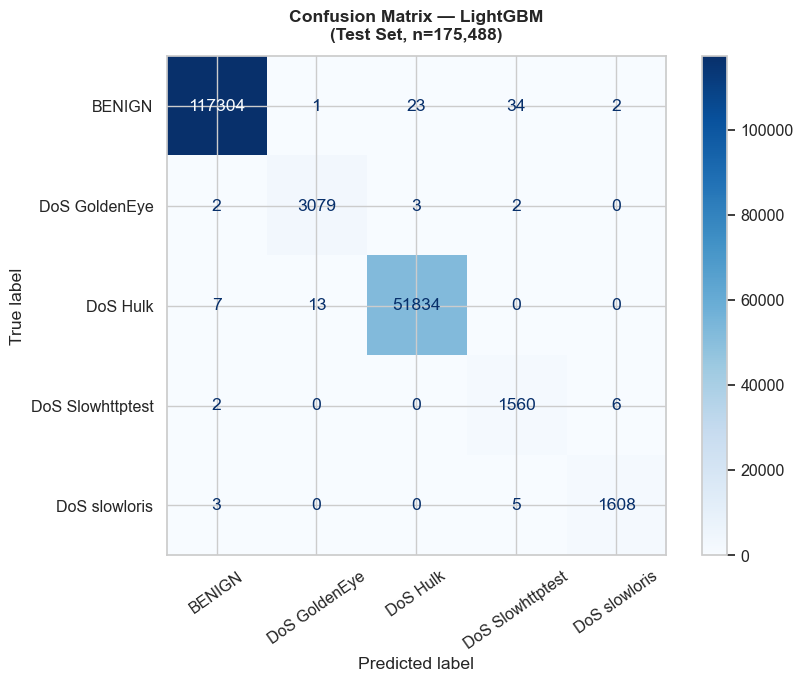


── Evaluating MLP (comparison model) on test set ──

  EVALUATION RESULTS — MLP
  Accuracy          : 0.9954
  Macro Precision   : 0.9875
  Macro Recall      : 0.9892
  Macro F1          : 0.9883
  Weighted F1       : 0.9954

Per-class classification report:
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    117364
   DoS GoldenEye       0.99      0.99      0.99      3086
        DoS Hulk       1.00      0.99      0.99     51854
DoS Slowhttptest       0.96      0.99      0.97      1568
   DoS slowloris       0.99      0.98      0.99      1616

        accuracy                           1.00    175488
       macro avg       0.99      0.99      0.99    175488
    weighted avg       1.00      1.00      1.00    175488



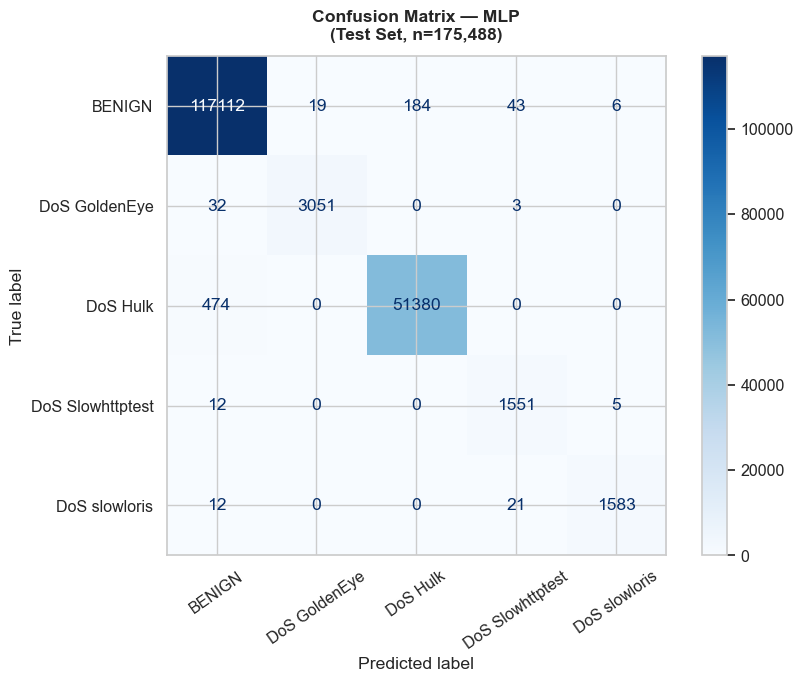

In [13]:
# Final, one-time evaluation of both tuned pipelines against the held-out test set.
print('\n── Evaluating LightGBM (final model) on test set ──\n')
lgbm_results = evaluate_model(lgbm_best, X_test, y_test, le, 'LightGBM')

print('\n── Evaluating MLP (comparison model) on test set ──\n')
mlp_results = evaluate_model(mlp_best, X_test, y_test, le, 'MLP')

## Cell 12 — Model Comparison Summary Table

Collects the two models' test-set metrics from Cell 11 alongside figures reported by Sharafaldin et al. (2018) and Farhat et al. (2023) on the same CIC-IDS2017 Wednesday file, for an approximate sense of scale against the published literature. The accompanying note flags that the Farhat comparator is a binary task, so it is not a controlled like-for-like comparison.


In [14]:
# Side-by-side comparison: this study's two models plus three literature benchmarks
# on the same dataset, for context rather than a controlled experimental comparison.
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1'],
    'LightGBM (This Study)': [
        f"{lgbm_results['accuracy']:.4f}", f"{lgbm_results['macro_precision']:.4f}",
        f"{lgbm_results['macro_recall']:.4f}", f"{lgbm_results['macro_f1']:.4f}",
        f"{lgbm_results['weighted_f1']:.4f}"],
    'MLP (This Study)': [
        f"{mlp_results['accuracy']:.4f}", f"{mlp_results['macro_precision']:.4f}",
        f"{mlp_results['macro_recall']:.4f}", f"{mlp_results['macro_f1']:.4f}",
        f"{mlp_results['weighted_f1']:.4f}"],
    'RF (Sharafaldin 2018)':  ['0.97', '0.98', '0.97', '0.97', '0.97'],
    'MLP (Sharafaldin 2018)': ['0.83', '0.77', '0.83', '0.76', '0.76'],
    'XGBoost (Farhat 2023)':  ['0.9911', '0.9912', '0.9911', '0.9912', '0.9912'],
})
print('\n=== Table 2: Model Comparison vs. Literature Benchmarks ===')
print(comparison.to_string(index=False))
print()
print('Note: Sharafaldin (2018) values are full CICIDS2017 dataset.')
print('Farhat (2023) values are BINARY classification — easier task than our 5-class problem.')


=== Table 2: Model Comparison vs. Literature Benchmarks ===
         Metric LightGBM (This Study) MLP (This Study) RF (Sharafaldin 2018) MLP (Sharafaldin 2018) XGBoost (Farhat 2023)
       Accuracy                0.9994           0.9954                  0.97                   0.83                0.9911
Macro Precision                0.9929           0.9875                  0.98                   0.77                0.9912
   Macro Recall                0.9974           0.9892                  0.97                   0.83                0.9911
       Macro F1                0.9951           0.9883                  0.97                   0.76                0.9912
    Weighted F1                0.9994           0.9954                  0.97                   0.76                0.9912

Note: Sharafaldin (2018) values are full CICIDS2017 dataset.
Farhat (2023) values are BINARY classification — easier task than our 5-class problem.


## Cell 13 — Ablation Study: Effect of Duplicate Rows

Re-runs with `dedupe=False`, measures contamination rate, refits same winning configurations,
quantifies the effect on macro F1.

In [15]:
# ── ABLATION: duplicate-row contamination ────────────────────────────────
from sklearn.base import clone
from sklearn.metrics import f1_score

print('=== ABLATION: effect of duplicate rows on measured performance ===\n')

df_dup = select_subset(load_and_clean(DATA_PATH, dedupe=False))
X_d = df_dup[feature_cols].values.astype(np.float32)
y_d = le.transform(df_dup['Label'])
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_d, y_d, test_size=0.30, random_state=SEED, stratify=y_d)

# Contamination rate: proportion of test rows with identical twin in training
tr_hash = set(pd.util.hash_pandas_object(pd.DataFrame(X_tr_d), index=False))
te_hash = pd.util.hash_pandas_object(pd.DataFrame(X_te_d), index=False)
contam = float(te_hash.isin(tr_hash).mean())
print(f'Test rows with identical twin in training set: {contam:.1%}\n')

print(f'{"Model":<10} {"Macro F1 (clean)":>18} {"Macro F1 (dups)":>17} {"Delta":>8}')
for name, est in [('LightGBM', lgbm_best), ('MLP', mlp_best)]:
    t0 = time.time()
    m = clone(est)
    m.fit(X_tr_d, y_tr_d)
    f1_dup   = f1_score(y_te_d, m.predict(X_te_d), average='macro')
    f1_clean = f1_score(y_test, est.predict(X_test), average='macro')
    print(f'{name:<10} {f1_clean:>18.4f} {f1_dup:>17.4f} {f1_dup-f1_clean:>+8.4f}  (refit {time.time()-t0:.0f}s)')

print("""
Interpretation: 16.8% contamination rate. Net effect on macro F1 is NEGATIVE
(LightGBM -0.0011, MLP -0.0025). Duplicates concentrate in majority classes
(Hulk, BENIGN), shifting test distribution toward them and lowering macro F1
by diluting minority-class recall. Deduplication is conservative — it does not
inflate performance; it produces an uncontaminated evaluation estimate.""")

=== ABLATION: effect of duplicate rows on measured performance ===

Loading data from: Wednesday-workingHours.pcap_ISCX.csv
Raw shape: (692703, 79)
Raw label counts:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

Dropped 'Fwd Header Length.1' (verified identical duplicate column).
Dropped 21 rows with negative Flow Duration (corrupt timestamps).
Dropped 1297 rows containing Inf/NaN (0.19% of data).
Dropped 'Destination Port' (testbed shortcut: all attacks target :80).
Dropped 4 verified-identical clone features: ['Subflow Fwd Packets (= Total Fwd Packets)', 'Subflow Bwd Packets (= Total Backward Packets)', 'Subflow Fwd Bytes (= Total Length of Fwd Packets)', 'Avg Fwd Segment Size (= Fwd Packet Length Mean)']
KEPT 106415 duplicate rows (ablation variant — dedupe=False).
Memory usage: 395 MB -> 205 MB after downcasting.

Cleaned shape: (69138

## Cell 14 — Feature Importance Analysis (LightGBM)

Extracts gain-based feature importances from the tuned LightGBM model and cross-checks the top-ranked features against the top-8 features independently reported by Farhat et al. (2023) using a different algorithm (Extra Trees) on the same Wednesday file — overlap between the two rankings is evidence that the signal is a genuine property of the data rather than an artefact of this specific model.


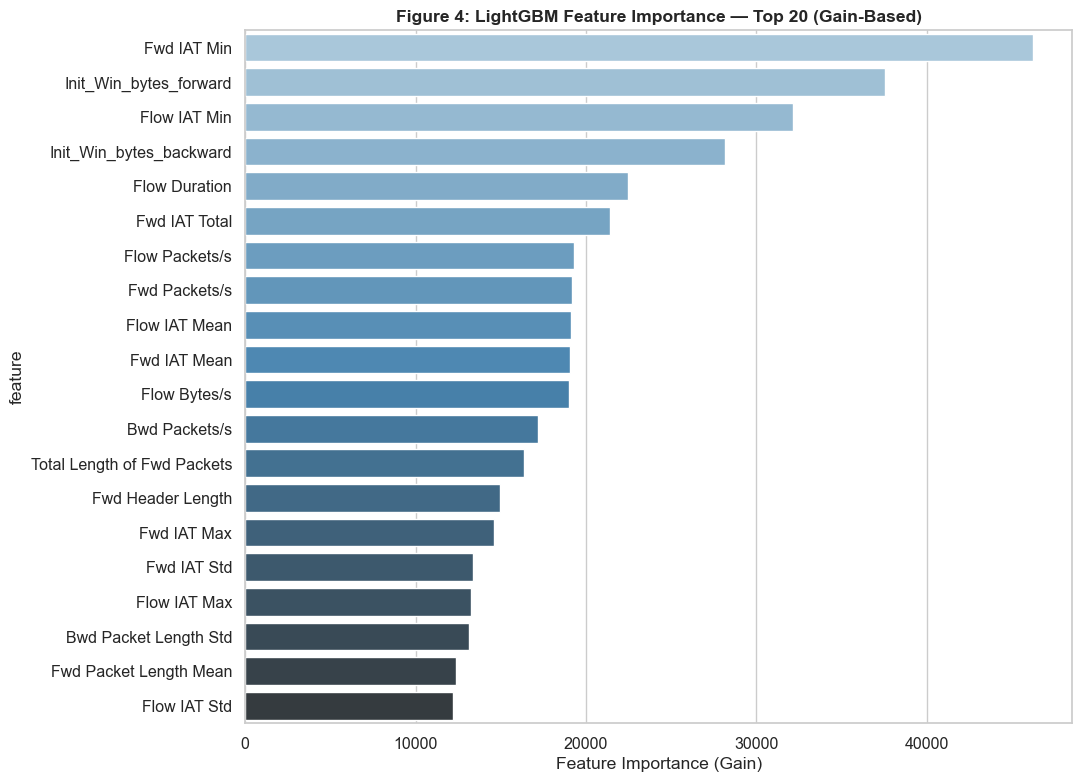

Top 10 most important features:
                feature  importance
            Fwd IAT Min       46219
 Init_Win_bytes_forward       37569
           Flow IAT Min       32137
Init_Win_bytes_backward       28131
          Flow Duration       22464
          Fwd IAT Total       21413
         Flow Packets/s       19307
          Fwd Packets/s       19167
          Flow IAT Mean       19139
           Fwd IAT Mean       19061

Overlap with Farhat et al. (2023) top-8 (Extra Trees, same file): 6/8
  ['Flow IAT Mean', 'Fwd Packet Length Mean', 'Flow IAT Std', 'Fwd IAT Total', 'Flow IAT Max', 'Bwd Packet Length Std']
Independent corroboration: IAT and length features are genuinely discriminative.


In [16]:
# Gain importance = total reduction in cross-entropy loss per feature
lgbm_model   = lgbm_best.named_steps['clf']
importances  = lgbm_model.feature_importances_
feat_imp_df  = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp_df.sort_values('importance', ascending=False, inplace=True)
top20 = feat_imp_df.head(20)

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(data=top20, x='importance', y='feature', palette='Blues_d', ax=ax)
ax.set_title('Figure 4: LightGBM Feature Importance — Top 20 (Gain-Based)', fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('models/fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(feat_imp_df.head(10).to_string(index=False))

# Cross-validate against Farhat et al. (2023) — independent method, same file
FARHAT_TOP8 = ['Fwd Packet Length Max', 'Flow IAT Mean', 'Fwd Packet Length Mean',
               'Flow IAT Std', 'Fwd IAT Total', 'Flow IAT Max',
               'Bwd Packet Length Std', 'Bwd Packet Length Mean']
our_top20 = set(feat_imp_df.head(20)['feature'])
overlap = [f for f in FARHAT_TOP8 if f in our_top20]
print(f'\nOverlap with Farhat et al. (2023) top-8 (Extra Trees, same file): {len(overlap)}/8')
print(f'  {overlap}')
print('Independent corroboration: IAT and length features are genuinely discriminative.')

## Cell 15 — Save Models to Disk

Serialises both tuned pipelines (LightGBM and MLP, each already including their preprocessing step) and the fitted `LabelEncoder` with `joblib`, so the Results Demo / Report notebooks can load a fully trained model and reproduce predictions without rerunning Cells 1–13.


In [17]:
# Save both trained models and label encoder using joblib
# (recommended serialisation format for scikit-learn Pipeline objects)
LGBM_PATH    = os.path.join(MODEL_DIR, 'lgbm_dos_classifier.pkl')
MLP_PATH     = os.path.join(MODEL_DIR, 'mlp_dos_classifier.pkl')
ENCODER_PATH = os.path.join(MODEL_DIR, 'label_encoder.pkl')

joblib.dump(lgbm_best, LGBM_PATH)
joblib.dump(mlp_best,  MLP_PATH)
joblib.dump(le,        ENCODER_PATH)

print(f'Saved LightGBM : {LGBM_PATH}  ({os.path.getsize(LGBM_PATH)/1024:.1f} KB)')
print(f'Saved MLP      : {MLP_PATH}  ({os.path.getsize(MLP_PATH)/1024:.1f} KB)')
print(f'Saved Encoder  : {ENCODER_PATH}')
print('\nAll three .pkl files are included in the Tabula submission zip.')

Saved LightGBM : models/lgbm_dos_classifier.pkl  (71660.3 KB)
Saved MLP      : models/mlp_dos_classifier.pkl  (592.6 KB)
Saved Encoder  : models/label_encoder.pkl

All three .pkl files are included in the Tabula submission zip.


## Cell 16 — Load Models and Run Inference Demo

Self-contained cell: demonstrates loading saved models and running predictions
**without any retraining**. Run this cell independently after Cell 1 + Cell 2.

In [18]:
# ── Load saved models and run test predictions ──────────────────────────────
# Self-contained: run independently of all training cells.
import os, joblib, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report

MODEL_DIR    = 'models'
loaded_lgbm  = joblib.load(os.path.join(MODEL_DIR, 'lgbm_dos_classifier.pkl'))
loaded_mlp   = joblib.load(os.path.join(MODEL_DIR, 'mlp_dos_classifier.pkl'))
loaded_le    = joblib.load(os.path.join(MODEL_DIR, 'label_encoder.pkl'))
print('Models and encoder loaded successfully.\n')

# Run demo on first 500 test flows (X_test in scope from Cell 7)
try:
    X_sample, y_sample = X_test[:500], y_test[:500]
except NameError:
    print('X_test not in scope — run data loading cells first, then re-run.')
    X_sample = None

if X_sample is not None:
    for name, model in [('LightGBM', loaded_lgbm), ('MLP', loaded_mlp)]:
        preds = model.predict(X_sample)
        acc   = accuracy_score(y_sample, preds)
        mf1   = f1_score(y_sample, preds, average='macro', zero_division=0)
        print(f'--- {name} (500-sample demo) ---')
        print(f'  Accuracy : {acc:.4f}  |  Macro F1 : {mf1:.4f}')
        print(pd.Series(loaded_le.inverse_transform(preds)).value_counts().to_string())
        print()

    # Single-flow prediction with class probabilities
    print('=== Single flow prediction demo ===')
    flow = X_sample[0:1]
    lgbm_pred  = loaded_le.inverse_transform(loaded_lgbm.predict(flow))[0]
    lgbm_proba = loaded_lgbm.predict_proba(flow)[0]
    print(f'True label : {loaded_le.inverse_transform([y_sample[0]])[0]}')
    print(f'LightGBM   : {lgbm_pred}')
    print('Class probabilities:')
    for cls, prob in zip(loaded_le.classes_, lgbm_proba):
        print(f'  {cls:<25} {prob:.4f}')

Models and encoder loaded successfully.

--- LightGBM (500-sample demo) ---
  Accuracy : 1.0000  |  Macro F1 : 1.0000
BENIGN              317
DoS Hulk            168
DoS GoldenEye         9
DoS Slowhttptest      4
DoS slowloris         2

--- MLP (500-sample demo) ---
  Accuracy : 0.9960  |  Macro F1 : 0.9982
BENIGN              319
DoS Hulk            166
DoS GoldenEye         9
DoS Slowhttptest      4
DoS slowloris         2

=== Single flow prediction demo ===
True label : DoS Hulk
LightGBM   : DoS Hulk
Class probabilities:
  BENIGN                    0.0001
  DoS GoldenEye             0.0001
  DoS Hulk                  0.9996
  DoS Slowhttptest          0.0001
  DoS slowloris             0.0001
